In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
from xgboost import XGBRegressor

print("XGBoost Installed Successfully")

XGBoost Installed Successfully


In [22]:
### 1. Linear Regression
from sklearn.linear_model import LinearRegression

In [23]:
### 2. Ridge Regression
from sklearn.linear_model import Ridge

In [24]:
### 3. Lasso Regression
from sklearn.linear_model import Lasso

In [25]:
### 4. ElasticNet Regression
from sklearn.linear_model import ElasticNet

In [26]:
### 5. Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

In [27]:
### 6. Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

In [28]:
### 7. Extra Trees Regressor
from sklearn.ensemble import ExtraTreesRegressor

In [29]:
### 8. Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

In [30]:
### 9. AdaBoost Regressor
from sklearn.ensemble import AdaBoostRegressor

In [31]:
### 10. XGBoost Regressor
from xgboost import XGBRegressor

In [32]:
### 11. K-Nearest Neighbors Regressor
from sklearn.neighbors import KNeighborsRegressor

In [33]:
### 12. Support Vector Regressor (SVR)
from sklearn.svm import SVR

In [34]:
### 13. Bayesian Ridge Regression
from sklearn.linear_model import BayesianRidge

In [35]:
### 14. Extra Tree Regressor
from sklearn.tree import ExtraTreeRegressor

In [36]:
### 15. Dummy Regressor
from sklearn.dummy import DummyRegressor

In [37]:
df = pd.read_csv('../data/data_YesBank_StockPrices.csv')

df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


In [39]:
df.isnull().sum()

Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

In [40]:
df['Date'] = pd.to_datetime(
    df['Date'],
    format='%b-%y'
)

In [42]:
X = df[['Open', 'High', 'Low']]

y = df['Close']

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [46]:
print(X_train.shape)
print(X_test.shape)

(148, 3)
(37, 3)


In [47]:
models = {

    'Linear Regression': LinearRegression(),

    'Ridge Regression': Ridge(),

    'Lasso Regression': Lasso(),

    'ElasticNet': ElasticNet(),

    'Decision Tree': DecisionTreeRegressor(),

    'Random Forest': RandomForestRegressor(),

    'Extra Trees': ExtraTreesRegressor(),

    'Gradient Boosting': GradientBoostingRegressor(),

    'AdaBoost': AdaBoostRegressor(),

    'XGBoost': XGBRegressor(),

    'KNN Regressor': KNeighborsRegressor(),

    'SVR': SVR(),

    'Bayesian Ridge': BayesianRidge(),

    'Extra Tree': ExtraTreeRegressor(),

    'Dummy Regressor': DummyRegressor()
}

In [48]:
results = []

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [50]:
for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mse = mean_squared_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

    print(name)

    print("MAE:", mae)

    print("MSE:", mse)

    print("RMSE:", rmse)

    print("R2 Score:", r2)

    print("-"*50)

Linear Regression
MAE: 5.812554509942109
MSE: 86.6437912651374
RMSE: 9.308264675283862
R2 Score: 0.9904142726548665
--------------------------------------------------
Ridge Regression
MAE: 5.81253138357335
MSE: 86.64366864942814
RMSE: 9.308258088892257
R2 Score: 0.9904142862203019
--------------------------------------------------
Lasso Regression
MAE: 5.8091332402583165
MSE: 86.64334560671395
RMSE: 9.308240736396645
R2 Score: 0.9904143219597281
--------------------------------------------------
ElasticNet
MAE: 5.811352241022145
MSE: 86.62684595080479
RMSE: 9.307354401268107
R2 Score: 0.9904161473784976
--------------------------------------------------
Decision Tree
MAE: 10.05297297297297
MSE: 268.3770108108107
RMSE: 16.382216297278298
R2 Score: 0.970308445489625
--------------------------------------------------
Random Forest
MAE: 8.754029729729718
MSE: 196.27805202891903
RMSE: 14.009926910191895
R2 Score: 0.9782850235070428
--------------------------------------------------
Extra Tr

In [51]:
results_df = pd.DataFrame(

    results,

    columns=[
        'Model',
        'MAE',
        'MSE',
        'RMSE',
        'R2 Score'
    ]
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,5.812555,86.643791,9.308265,0.990414
1,Ridge Regression,5.812531,86.643669,9.308258,0.990414
2,Lasso Regression,5.809133,86.643346,9.308241,0.990414
3,ElasticNet,5.811352,86.626846,9.307354,0.990416
4,Decision Tree,10.052973,268.377011,16.382216,0.970308
5,Random Forest,8.754030,196.278052,14.009927,0.978285
6,Extra Trees,7.706270,155.344096,12.463711,0.982814
7,Gradient Boosting,8.685311,183.475311,13.545306,0.979701
8,AdaBoost,9.537170,224.496336,14.983202,0.975163
9,XGBoost,10.037983,231.606793,15.218633,0.974376


In [52]:
results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
3,ElasticNet,5.811352,86.626846,9.307354,0.990416
12,Bayesian Ridge,5.810823,86.636890,9.307894,0.990415
2,Lasso Regression,5.809133,86.643346,9.308241,0.990414
1,Ridge Regression,5.812531,86.643669,9.308258,0.990414
0,Linear Regression,5.812555,86.643791,9.308265,0.990414
6,Extra Trees,7.706270,155.344096,12.463711,0.982814
7,Gradient Boosting,8.685311,183.475311,13.545306,0.979701
5,Random Forest,8.754030,196.278052,14.009927,0.978285
8,AdaBoost,9.537170,224.496336,14.983202,0.975163
9,XGBoost,10.037983,231.606793,15.218633,0.974376


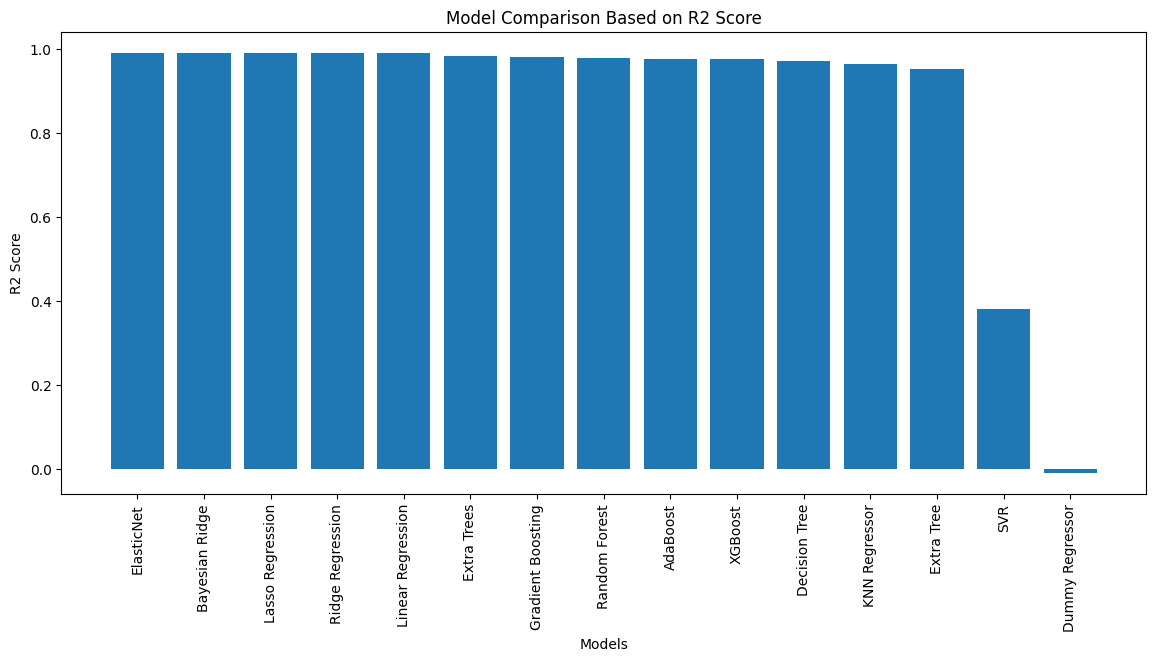

In [53]:
plt.figure(figsize=(14,6))

plt.bar(
    results_df['Model'],
    results_df['R2 Score']
)

plt.xticks(rotation=90)

plt.title('Model Comparison Based on R2 Score')

plt.xlabel('Models')

plt.ylabel('R2 Score')

plt.show()

In [54]:
best_model = RandomForestRegressor()

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

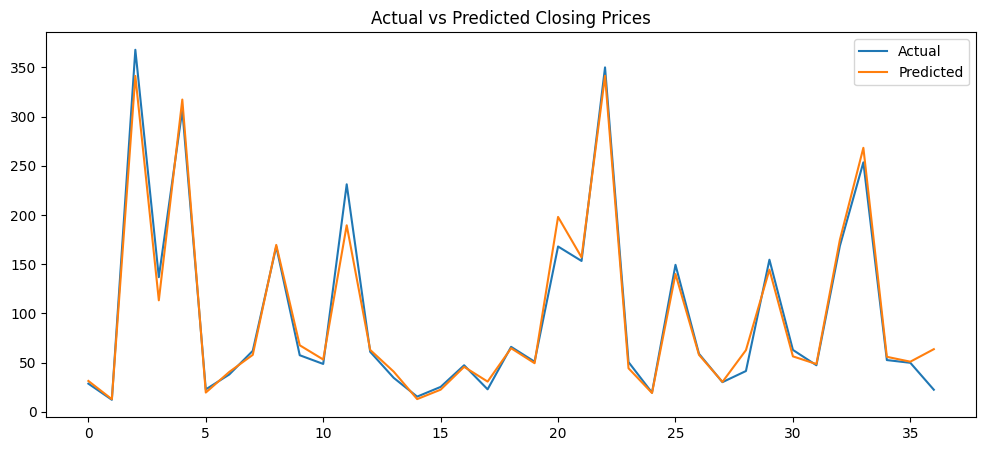

In [55]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    predictions,
    label='Predicted'
)

plt.legend()

plt.title('Actual vs Predicted Closing Prices')

plt.show()

In [56]:
importance = best_model.feature_importances_

features = X.columns

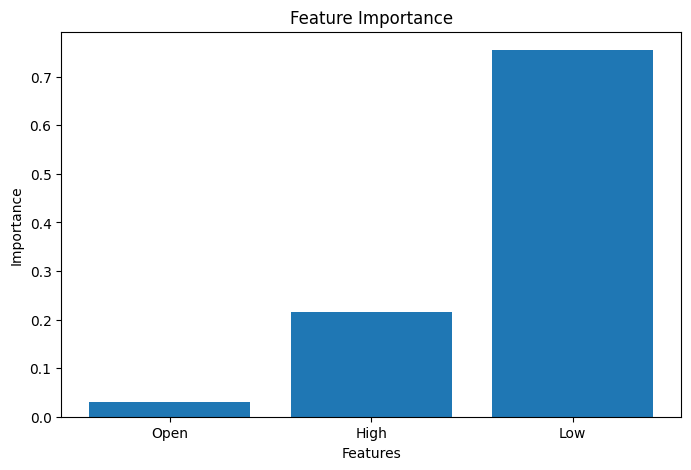

In [57]:
plt.figure(figsize=(8,5))

plt.bar(
    features,
    importance
)

plt.title('Feature Importance')

plt.xlabel('Features')

plt.ylabel('Importance')

plt.show()

In [58]:
import joblib

joblib.dump(
    best_model,
    '../outputs/best_model.pkl'
)

['../outputs/best_model.pkl']

### Conclusion:-

-> In this project, multiple machine learning regression models were implemented to predict the closing price of Yes Bank stocks using historical stock market data.

-> Different algorithms such as Linear Regression, Decision Tree, Random Forest, XGBoost, Gradient Boosting, Support Vector Regressor, and several other regression models were trained and evaluated using MAE, MSE, RMSE, and R2 Score metrics.

-> The comparison of different models helped identify the best-performing algorithm for stock price prediction. Ensemble learning models such as Random Forest and XGBoost achieved better prediction accuracy compared to basic regression models.

-> The project successfully demonstrated how machine learning techniques can be applied to financial datasets for analyzing stock market trends and predicting future stock prices.